# Paths and Clustering

## Importing Packages

In [ ]:
import networkx as nx
import numpy as np
%matplotlib inline

## Creating a [Small World] Network

To start talking about paths and distances between nodes, it helps to have a network to discuss. Here's a quick generated network. This particular network will be a small world network, which you'll learn more about in some upcoming lessons.

//anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
//anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:676: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if cb.iterable(node_size):  # many node sizes


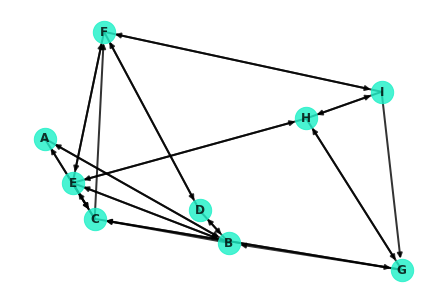

In [ ]:
G = nx.navigable_small_world_graph(3, seed=3)
G = nx.relabel_nodes(G, dict(zip(G.nodes, ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'])))
nx.draw(G, pos=nx.random_layout(G, seed=9), with_labels=True, node_color='#1cf0c7',
        node_size=500, font_weight='bold', width=2, alpha=0.8)

## Retrieving Shortest Paths with NetworkX

NetworkX contains easy methods for finding the shortest paths between nodes. Most require you to pass in the network, starting node, and ending node. 

You can check if there is a path between two nodes:

In [ ]:
nx.has_path(G, 'F', 'G')

True

You can find the shortest path which returns a list of nodes roadmapping how to hop from the starting node to the destination node:

In [ ]:
nx.shortest_path(G, 'F', 'G')

['F', 'I', 'G']

Or you can directly access the lenght of the shortest path:

In [ ]:
nx.shortest_path_length(G, 'F', 'G')

2

The algorithm underlying these methods is known as Dijkstra's algorithm. You'll take a look at how the algorithm itself works soon. In the meantime, it's worth noting that the last two methods are also accessible under another method name paying homage to their creator:

> Note: going forward, we will exclusively use the `nx.dijkstra...()` methods in lieu of the `nx.shortest_path...()` counterparts.

In [ ]:
nx.dijkstra_path(G, 'F', 'G')

['F', 'I', 'G']

In [ ]:
nx.dijkstra_path_length(G, 'F', 'G')

2

## Visualizing a Path

Now that you've seen how to use NetworkX to retrieve the shortest paths between nodes, let's take a look at how you can visualize said paths. For example, the shortest path between `F` and `G` looks like this:
<img name='final_path_viz' src='assets/07_graph_theory_shortest_path/path.png'> 

## Accessing Edges

In [ ]:
G.edges

OutEdgeView([('A', 'B'), ('A', 'C'), ('B', 'A'), ('B', 'D'), ('B', 'E'), ('B', 'C'), ('C', 'A'), ('C', 'E'), ('C', 'G'), ('C', 'F'), ('D', 'B'), ('D', 'F'), ('D', 'D'), ('E', 'B'), ('E', 'C'), ('E', 'F'), ('E', 'H'), ('F', 'D'), ('F', 'E'), ('F', 'I'), ('G', 'C'), ('G', 'H'), ('G', 'B'), ('H', 'E'), ('H', 'G'), ('H', 'I'), ('I', 'F'), ('I', 'H'), ('I', 'G')])

## Retrieving a specific Edge

You can retrieve a specific edge similar to retrieving an item from a dictionary:

In [ ]:
G.edges[('F', 'E')]

{}

While the entry is uninformative (there are no weights and no properties set), the mere existence of a response (and not hitting a key error) indicates that the edge exists. For example, the following returns an error as there is no out edge from F to A:

In [ ]:
G.edges[('F', 'A')]

KeyError: 'A'

## Retrieving Outbound Connections for a Given Node

In [ ]:
G['F']

AtlasView({'D': {}, 'E': {}, 'I': {}})

> **Warning:** Some of the edges in the network graph are difficult to see as they overlap or can be running through other nodes. For example, note from the display below how node C is actually connected to nodes A and G! These edges are virtually impossible to notice with the current drawing of the graph.

In [ ]:
G['C']

AtlasView({'A': {}, 'E': {}, 'G': {}, 'F': {}})

## Coloring Edges

//anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:585: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  and cb.iterable(edge_color) \


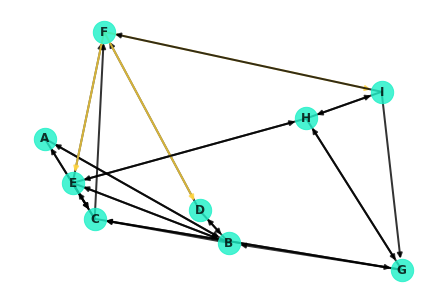

In [ ]:
colors = []
for edge in G.edges:
    # To learn more about what's happening, uncomment this line (warning: verbose printout!)
     # print(type(edge), edge) 
    if edge[0] == 'F':
        colors.append('#ffd43d')
    else:
        colors.append('black')
nx.draw(G, pos=nx.random_layout(G, seed=9), with_labels=True, node_color='#1cf0c7',
        node_size=500, font_weight='bold', width=2, alpha=.8, edge_color=colors)

Well, this isn't ideal. Note that the node from F to I is extremely hard to see! It's covered up by the edge from I to F. As a hacky little workaround, you can redraw the specific edges in question.

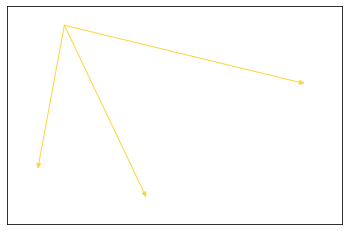

In [ ]:
nx.draw_networkx_edges(G, nx.random_layout(G, seed=9), [e for e in G.edges() if e[0]=='F'], edge_color='#ffd43d');

Overlaying these on the entire graph:

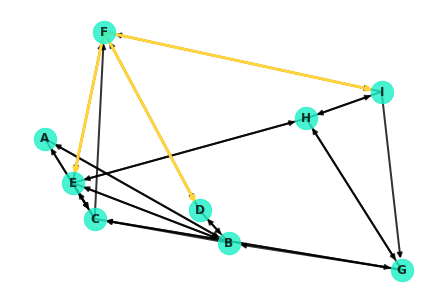

In [ ]:
nx.draw(G, pos=nx.random_layout(G, seed=9), with_labels=True, node_color='#1cf0c7',
        node_size=500, font_weight='bold', width=2, alpha=0.8, edge_color='black')
nx.draw_networkx_edges(G, edgelist=[e for e in G.edges() if e[0]=='F'], pos=nx.random_layout(G, seed=9),
                       width=3, edge_color='#ffd43d');

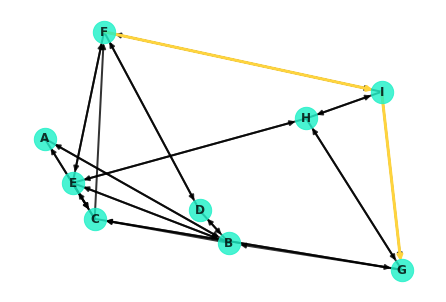

In [ ]:
nx.draw(G, pos=nx.random_layout(G, seed=9), with_labels=True, node_color='#1cf0c7',
        node_size=500, font_weight='bold', width=2, alpha=0.8)
nx.draw_networkx_edges(G, nx.random_layout(G, seed=9), width=3,
                       edgelist=[('F', 'I'), ('I','G')], edge_color='#ffd43d');

## Under the Hood: Dijkstra's Algorithm

Dijkstra's algorithm is essentially a depth based search. It commences at the starting node, spanning out to neighboring nodes and in turn visiting their neighbors in search of the destination. More formally, here's a general pseudo-code outline for the algorithm:

1. Mark all nodes as unvisited
2. Set the distance of the starting node as 0, and $\infty$ for all other nodes
3. Set the starting node as the current node
4. Visit each of the neighbors of the current node
    1. For each neighbor, calculate the distance to that node traveling through the current node
    2. If this distance is less then the current distance recorded for that node, update the record accordingly
5. Mark the current node as 'visited'
6. Of the unvisited nodes, set the one with the smallest distance to the current node
7. Repeat steps 4 through 6 until one of the following:
    1. The algorithm terminates when the destination node is the current node
    2. Alternatively, if the smallest distance of the unvisited nodes is $\infty$, then no path exists to the destination node  

> Note: Dijkstra's algorithm (and NetworkX's implementations demonstrated above) returns a single path. In many cases, there may be multiple paths which are tied for the shortest distance between two nodes. In such cases, it is arbitrary which path is returned.

In the upcoming lab, you'll work to code this classic algorithm on your own!

---

## Importing Packages

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Regenerating the [Small World] Network

To get started, here's the network from the previous lesson:

C:\Anaconda3\envs\learn-tf\lib\site-packages\networkx\drawing\nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
C:\Anaconda3\envs\learn-tf\lib\site-packages\networkx\drawing\nx_pylab.py:676: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if cb.iterable(node_size):  # many node sizes


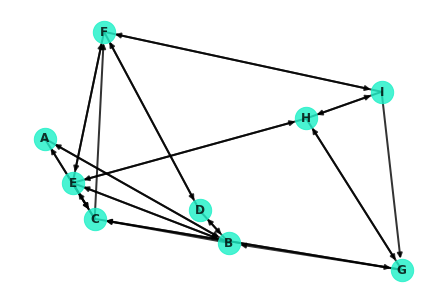

In [ ]:
G = nx.navigable_small_world_graph(3, seed=3)
G = nx.relabel_nodes(G, dict(zip(G.nodes, ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'])))
nx.draw(G, pos=nx.random_layout(G, seed=9), with_labels=True, node_color='#1cf0c7',
        node_size=500, font_weight='bold', width=2, alpha=0.8)

## Dijkstra's Algorithm

As a helpful reference, here's the description of Dijkstra's Algorithm from the previous lesson:


Dijkstra's algorithm is essentially a depth based search. It commences at the starting node, spanning out to neighboring nodes and in turn visiting their neighbors in search of the destination. More formally, here's a general pseudocode outline for the algorithm:

1. Mark all nodes as unvisited
2. Set the distance of the starting node as 0, and $\infty$ for all other nodes
3. Set the starting node as the current node
4. Visit each of the neighbors of the current node
    1. For each neighbor, calculate the distance to that node traveling through the current node
    2. If this distance is less then the current distance recorded for that node, update the record accordingly
5. Mark the current node as "visited"
6. Of the unvisited nodes, set the one with the smallest distance to the current node
7. Repeat steps 4 through 6 until one of the following:
    1. The algorithm terminates when the destination node is the current node
    2. Alternatively, if the smallest distance of the unvisited nodes is $\infty$, then no path exists to the destination node. 

> Note: Dijkstra's algorithm (and NetworkX's implementations demonstrated above) returns a single path. In many cases, there may be multiple paths which are tied for the shortest distance between two nodes. In such cases, it is arbitrary which path is returned. 


## Coding Dijkstra's Algorithm (Part 1)

Implement a function to perform Dijkstra's algorithm. The function should take in three parameters: the graph `G`, the starting node `u`, and the destination node `v`. From there, return the minimum distance between nodes `u` and `v`. In the case that there is no path connecting `u` and `v`, printout an appropriate notification and return a missing value (`np.nan`).

In [ ]:
def dijkstra(G, u, v):
    """
    G is the graph in question
    u is the starting node
    v is the destination node
    """
    pass

Test out your function on a couple of node pairs, and compare the output to that of NetworkX's built in implementation to verify your results.

In [ ]:
# Test your function here

In [ ]:
# Compare to NetworkX's built in method

## Coding Dijkstra's Algorithm (Part 2)

Now, update your algorithm to not only return the minimum distance between the two points, but a list of nodes outlining the directions for the shortest path from the starting node to the destination node. The direction list of nodes should start with the starting node, and end with the destination node, with intermediate step nodes in between. For example, just like the built in method from NetworkX:  

```python
nx.dijkstra_path(G, 'I', 'A')
```
should return 

```python
['I', 'G', 'C', 'A']
```

In [ ]:
def dijkstra(G, u, v, return_path_directions=True):
    """
    G is the graph in question
    u is the starting node
    v is the destination node
    """

Now check your updated function against the built in methods from NetworkX again.

In [ ]:
# Your code here

## Level-Up: Creating a Visual

Modify your function in order to produce successive plots to visualize the process of Dijkstra's algorithm. Plot the edges connecting the starting node to "visited" nodes using one color (ideally, `'#00b3e6'`). Then, plot the current edge connecting the current node to the neighbor being explored with another color (ideally, `'#ffd43d'`). Create a subplot of these graphs to show the process of the algorithm.

Putting these plots together, you can also create a fun interactive visual of Dijkstra's algorithm!
Here's what the search for the shortest path between `F` and `G` looks like:

<img src="assets/08_graph_theory_shortest_path_lab/Dijkstra_Visualized.gif">

Or broken apart, here are the individual steps shown as subplots:

<img src="assets/08_graph_theory_shortest_path_lab/dijkstra_subplots.png">

In [ ]:
def dijkstra(G, u, v, return_path_directions=True, show_plots=True):
    
    """
    G is the graph in question
    u is the starting node
    v is the destination node
    
    Returns path, distance
    """

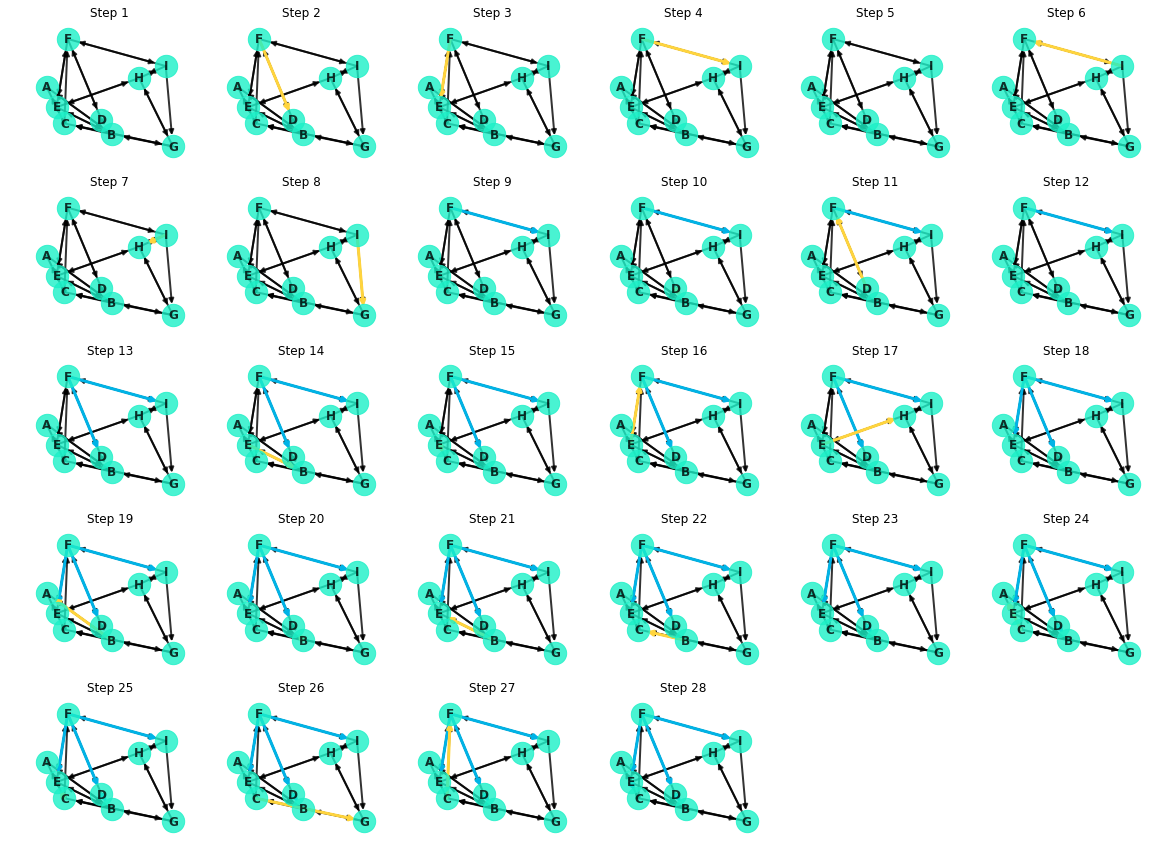

In [ ]:
dijkstra(G, 'F', 'G')

---

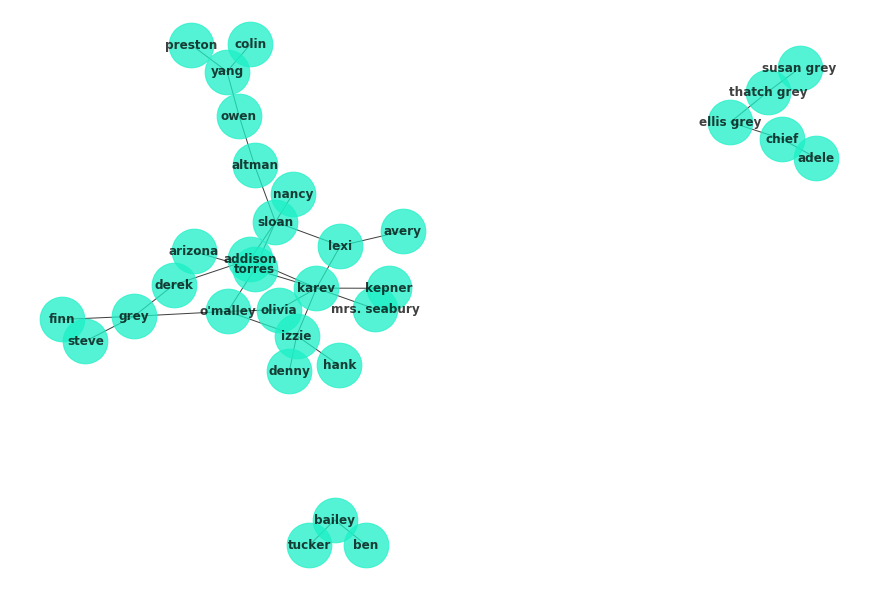

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline
G = nx.read_gexf('ga_graph.gexf')
plt.figure(figsize=(12,8))
nx.draw(G, with_labels=True, node_color='#1cf0c7',
        alpha=.75, font_weight='bold', node_size=2*10**3, pos=nx.spring_layout(G, seed=4))

In [ ]:
c = list(nx.algorithms.community.k_clique_communities(G, k=2))
c

[frozenset({'addison',
            'altman',
            'arizona',
            'avery',
            'colin',
            'denny',
            'derek',
            'finn',
            'grey',
            'hank',
            'izzie',
            'karev',
            'kepner',
            'lexi',
            'mrs. seabury',
            'nancy',
            "o'malley",
            'olivia',
            'owen',
            'preston',
            'sloan',
            'steve',
            'torres',
            'yang'}),
 frozenset({'adele', 'chief', 'ellis grey', 'susan grey', 'thatch grey'}),
 frozenset({'bailey', 'ben', 'tucker'})]

In [ ]:
colors = [('teal', '#1cf0c7'),
         ( 'workzone_yellow', '#ffd43d'),
         ('light-blue', '#00b3e6'),
         ('medium-blue', '#32cefe'),
         ('gray', '#efefef'),
         ('slate', '#2b2b2b'),
         ('dark-blue', '#144ff')]
color_dict = dict(colors)

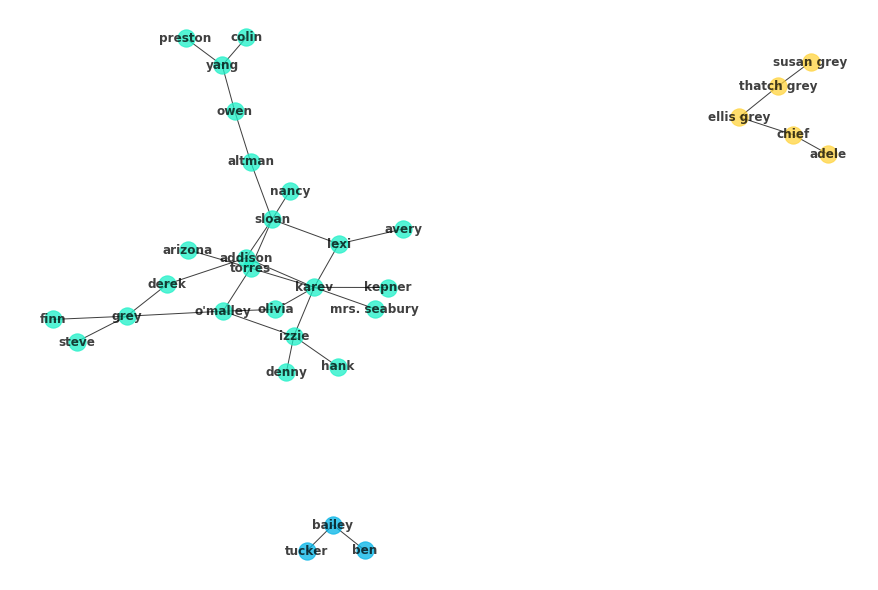

In [ ]:
fig = plt.figure(figsize=(12,8))
for n, ci in enumerate(c):
    ci = G.subgraph(ci)
    nx.draw(ci, with_labels=True, node_color=colors[n][1],
            alpha=.75, font_weight='bold', pos=nx.spring_layout(G, seed=4))

## The Girvan Newman Algorithm in NetworkX

As discussed, the Girvan Newman algorithm works by successively removing edges which are considered to be strong ties between subsets in the community. Typically, this is the betweenness metric. Since you are removing edges in the algorithm, betweenness is calculated for the edges as opposed to the nodes, as you have previously seen. The process is nearly identical though. First, the shortest paths between all nodes are computed using Dijkstra's algorithm. From there, an edges betweenness is the fraction of these paths that the edge is part of.

Implementing the algorithm with NetworkX is straightforward. See the documentation for passing alternative metrics then betweenness through the algorithm.

In [ ]:
c_gn = list(nx.algorithms.community.centrality.girvan_newman(G))
print(len(c_gn), c_gn[:3])

29 [({'finn', 'derek', 'mrs. seabury', 'kepner', 'nancy', 'addison', 'avery', 'grey', 'torres', 'izzie', 'olivia', 'lexi', 'karev', "o'malley", 'denny', 'arizona', 'hank', 'steve', 'sloan'}, {'ellis grey', 'chief', 'thatch grey', 'adele', 'susan grey'}, {'ben', 'bailey', 'tucker'}, {'owen', 'colin', 'preston', 'altman', 'yang'}), ({'addison', 'avery', 'nancy', 'karev', "o'malley", 'denny', 'arizona', 'hank', 'mrs. seabury', 'torres', 'kepner', 'olivia', 'izzie', 'sloan', 'lexi'}, {'ellis grey', 'chief', 'thatch grey', 'adele', 'susan grey'}, {'ben', 'bailey', 'tucker'}, {'finn', 'derek', 'steve', 'grey'}, {'owen', 'colin', 'preston', 'altman', 'yang'}), ({'addison', 'avery', 'nancy', 'karev', "o'malley", 'arizona', 'mrs. seabury', 'torres', 'kepner', 'olivia', 'sloan', 'lexi'}, {'ellis grey', 'chief', 'thatch grey', 'adele', 'susan grey'}, {'hank', 'denny', 'izzie'}, {'ben', 'bailey', 'tucker'}, {'finn', 'derek', 'steve', 'grey'}, {'owen', 'colin', 'preston', 'altman', 'yang'})]


> Comment: Note how there is a large number of results! Each is a list of clusters formed by removing the `n` strongest edges according to the metric specified.

In [ ]:
c_gn[0]

({'addison',
  'arizona',
  'avery',
  'denny',
  'derek',
  'finn',
  'grey',
  'hank',
  'izzie',
  'karev',
  'kepner',
  'lexi',
  'mrs. seabury',
  'nancy',
  "o'malley",
  'olivia',
  'sloan',
  'steve',
  'torres'},
 {'adele', 'chief', 'ellis grey', 'susan grey', 'thatch grey'},
 {'bailey', 'ben', 'tucker'},
 {'altman', 'colin', 'owen', 'preston', 'yang'})

In [ ]:
colors = [('teal', '#1cf0c7'),
         ( 'workzone_yellow', '#ffd43d'),
         ('light-blue', '#00b3e6'),
         ('medium-blue', '#32cefe'),
         ('gray', '#efefef'),
         ('slate', '#2b2b2b'),
         ('dark-blue', '#1443ff')]

Since there are so many individual clusters, take a look at the first four results of removing successive edges:

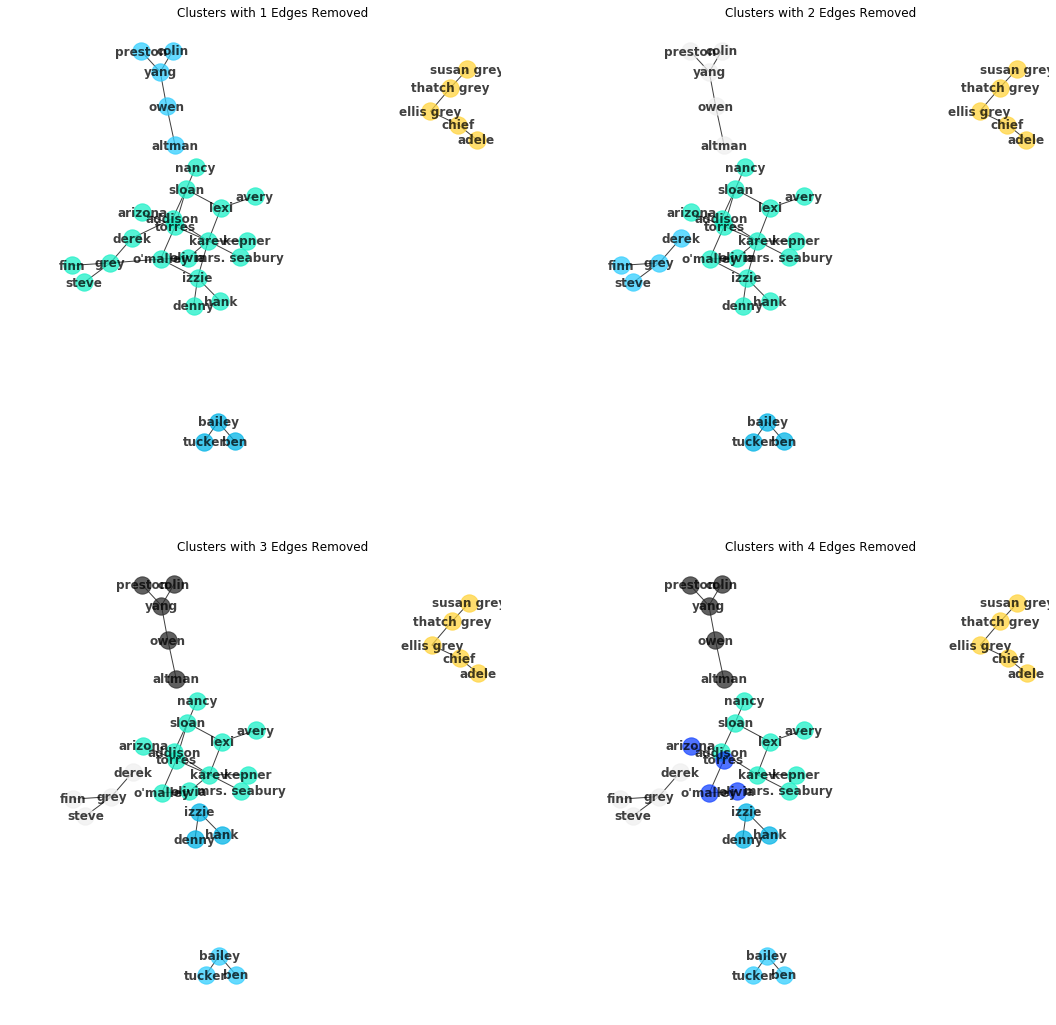

In [ ]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(18,18))
for n, cs in enumerate(c_gn[:4]):
    i = n//2
    j = n%2
    ax = axes[i][j]
    ax.set_title('Clusters with {} Edges Removed'.format(n+1))
    #Multiple Clusters per Groups
    for n2, c in enumerate(cs):
        ci = G.subgraph(c)
        color = colors[n2][1]
        nx.draw(ci, with_labels=True, node_color=color, ax=ax,
                alpha=.75, font_weight='bold', pos=nx.spring_layout(G, seed=4));

And of course if you look at the last set, all of the nodes should be individually displayed, since all of the edges have been removed:

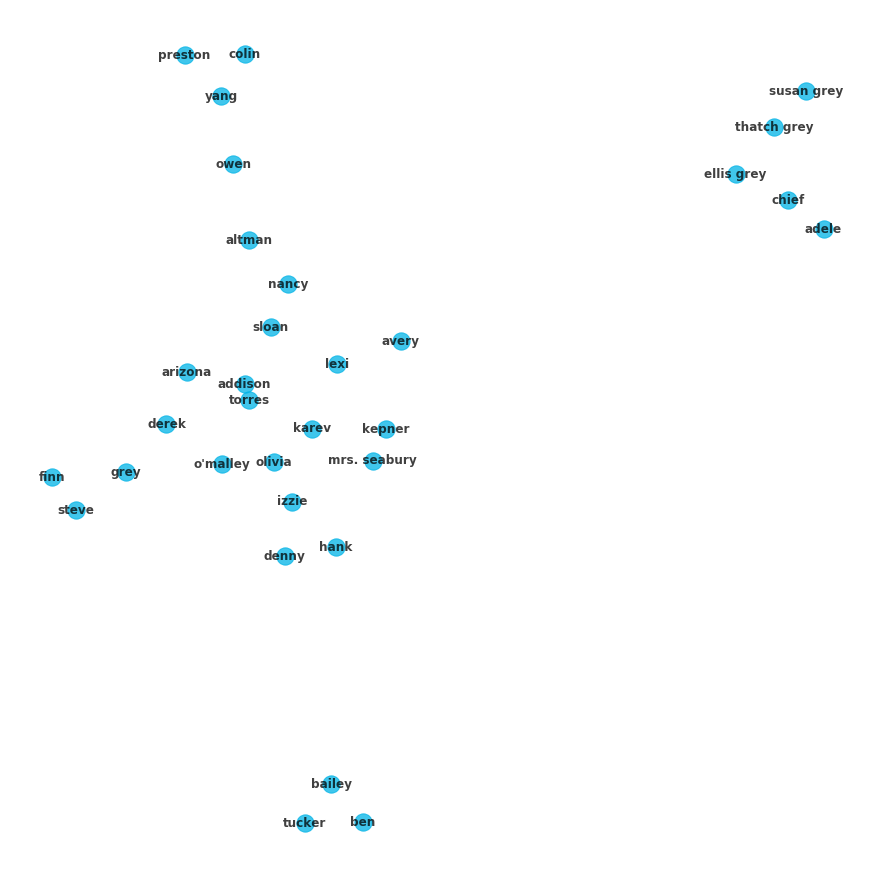

In [ ]:
cs = c_gn[-1]
fig = plt.figure(figsize=(12,12))
for c in cs:
    ci = G.subgraph(c)
    nx.draw(ci, with_labels=True, node_color=color_dict['light-blue'],
                alpha=.75, font_weight='bold', pos=nx.spring_layout(G, seed=4));

---

## Load the Dataset

Load the data from the `'data/stack-overflow-tag-network/stack_network_links.csv'` file. For now, simply load the file as a standard pandas DataFrame.

In [ ]:
# Your code here

## Transform the Dataset into a Network Graph using NetworkX

Transform the dataset from a Pandas DataFrame into a NetworkX graph.

In [ ]:
# Your code here

## Create an Initial Graph Visualization

Next, create an initial visualization of the network.

In [ ]:
# Your code here

## Perform an Initial Clustering using k-clique Clustering

Begin to explore the impact of using different values of k.

In [ ]:
# Your code here

## Visualize The Clusters Produced from the K-Clique Algorithm

> **Level-Up:** Experiment with different `nx.draw()` settings. See the [draw documentation here](https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.drawing.nx_pylab.draw_networkx.html) for a full list. Some recommended settings that you've previewed include the position parameter `pos`, `with_labels=True`, `node_color`, `alpha`, `node_size`, `font_weight` and `font_size`. Note that `nx.spring_layout(G)` is particularly useful for laying out a well formed network. With this, you can pass in parameters for the relative edge distance via `k` and set a `random_seed` to have reproducible results as in `nx.spring_layout(G, k=2.66, seed=10)`. For more details, see the [spring_layout documentation here](https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.drawing.layout.spring_layout.html?highlight=spring%20layout#networkx.drawing.layout.spring_layout).

In [ ]:
# Your code here

In [ ]:
# Your code here

## Perform an Alternative Clustering Using the Girvan-Newman Algorithm

Recluster the network using the Girvan-Newman algorithm. Remember that this will give you a list of cluster lists corresponding to the clusters that from removing the top $n$ edges according to some metric, typically edge betweenness.

In [ ]:
# Your code here

## Create a Visualization Wrapper

Now that you have an idea of how splintered the network becomes based on the number of edges removed, you'll want to examine some of the subsequent groups that gradually break apart. Since the network is quiet complex to start with, using subplots is not a great option; each subplot would be too small to accurately read. Create a visualization function `plot_girvan_newman(G, clusters)` which takes a NetworkX graph object as well as one of the clusters from the output of the Girvan-Newman algorithm above and plots the network with a unique color for each cluster.

> **Level-Up:** Experiment with different `nx.draw()` settings. See the [draw documentation here](https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.drawing.nx_pylab.draw_networkx.html) for a full list. Some recommended settings that you've previewed include the position parameter `pos`, `with_labels=True`, `node_color`, `alpha`, `node_size`, `font_weight` and `font_size`. Note that `nx.spring_layout(G)` is particularly useful for laying out a well formed network. With this, you can pass in parameters for the relative edge distance via `k` and set a `random_seed` to have reproducible results as in `nx.spring_layout(G, k=2.66, seed=10)`. For more details, see the [spring_layout documentation here](https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.drawing.layout.spring_layout.html?highlight=spring%20layout#networkx.drawing.layout.spring_layout).

In [ ]:
def plot_girvan_newman(G, clusters):
    # Your code here 
    pass

## Visualize the Various Clusters that Form Throughout the Girvan-Newman Algorithm

Use your function to visualize the various clusters that form throughout the Girvan-Newman algorithm as you remove more and more edges from the network.

In [ ]:
# Your code here

## Cluster Decay Rate

Create a visual to help yourself understand the rate at which clusters of this network formed versus the number of edges removed.

> **Level-Up**: Based on your graphic, what would you predict is an appropriate number of clusters?

In [ ]:
# Your code here

## Choose a Clustering 

Now that you have generated various clusters within the overall network, which do you think is the most appropriate or informative?

In [ ]:
# Your code/response here